# TFT Set 17 — Exploratory Data Analysis
Loads `data/tft_clean.csv` produced by `01_build_data.ipynb`.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/tft_clean.csv")
df["date"]  = pd.to_datetime(df["date"])
df["is_me"] = df["is_me"].astype(bool)

me = df[df["is_me"]]
chall = df[~df["is_me"]]

print(f"{len(df):,} rows  |  {df['is_me'].sum()} my games  |  {(~df['is_me']).sum()} challenger games")
print(f"Columns: {len(me.columns)}")
df.head()

1,556 rows  |  74 my games  |  1482 challenger games
Columns: 84


,match_id,date,player_name,is_me,placement,level,last_round,stage_round,gold_left,damage_to_players,...,trait_Stargazer_Medallion,trait_Stargazer_Mountain,trait_Stargazer_Serpent,trait_Stargazer_Shield,trait_Stargazer_Wolf,trait_SummonTrait,trait_TahmKenchUniqueTrait,trait_Timebreaker,trait_VexUniqueTrait,trait_ZedUniqueTrait
0,NA1_5562880650,2026-05-18 04:53:11.410,me,True,4,9,34,6-5,0,105,...,0,0,0,0,0,0,3,0,0,0
1,NA1_5560691122,2026-05-15 05:37:09.012,me,True,6,9,31,6-2,7,110,...,0,0,0,0,0,1,0,0,0,0
2,NA1_5559979852,2026-05-14 05:08:10.272,me,True,4,9,35,7-1,1,143,...,0,0,0,0,0,0,3,0,0,0
3,NA1_5559669327,2026-05-13 23:18:42.862,me,True,5,9,31,6-2,1,94,...,0,0,0,0,0,1,0,0,3,0
4,NA1_5559167035,2026-05-13 03:01:23.733,me,True,5,8,31,6-2,19,83,...,0,0,0,0,0,1,0,0,0,0


## 1. Sanity check — placement distribution

In [21]:
print(df["is_me"].value_counts())

is_me
False    1482
True       74
Name: count, dtype: int64


C:\Users\jshih\AppData\Local\Temp\ipykernel_1348\418481747.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="group", y="placement",


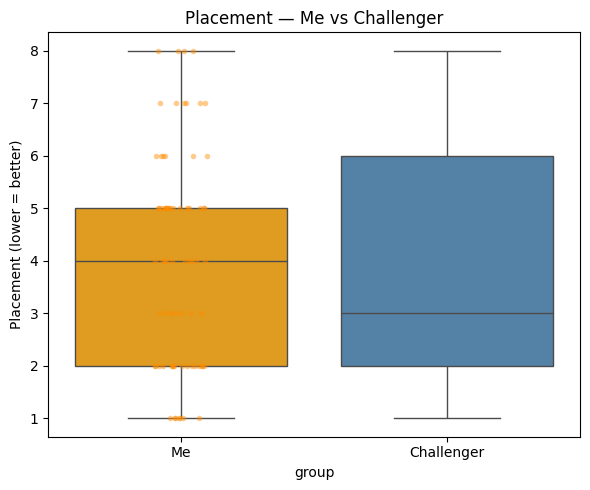

Me    — median: 4  mean: 4.03
Chall — median: 3  mean: 3.78


In [22]:
plot_df = pd.concat([
    me[["placement"]].assign(group="Me"),
    chall[["placement"]].assign(group="Challenger")
])

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=plot_df, x="group", y="placement",
            palette={"Me": "orange", "Challenger": "steelblue"},
            order=["Me", "Challenger"], ax=ax)
sns.stripplot(data=plot_df[plot_df["group"] == "Me"],
              x="group", y="placement",
              color="darkorange", alpha=0.45, size=4, jitter=True, ax=ax)
ax.set_title("Placement — Me vs Challenger")
ax.set_ylabel("Placement (lower = better)")
ax.set_yticks(range(1, 9))
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

print(f"Me    — median: {me['placement'].median():.0f}  mean: {me['placement'].mean():.2f}")
print(f"Chall — median: {chall['placement'].median():.0f}  mean: {chall['placement'].mean():.2f}")

## 2. Bivariate — mean feature value by placement
The headline plot: which features actually carry signal.

## 3. Me vs Challenger — distribution overlays

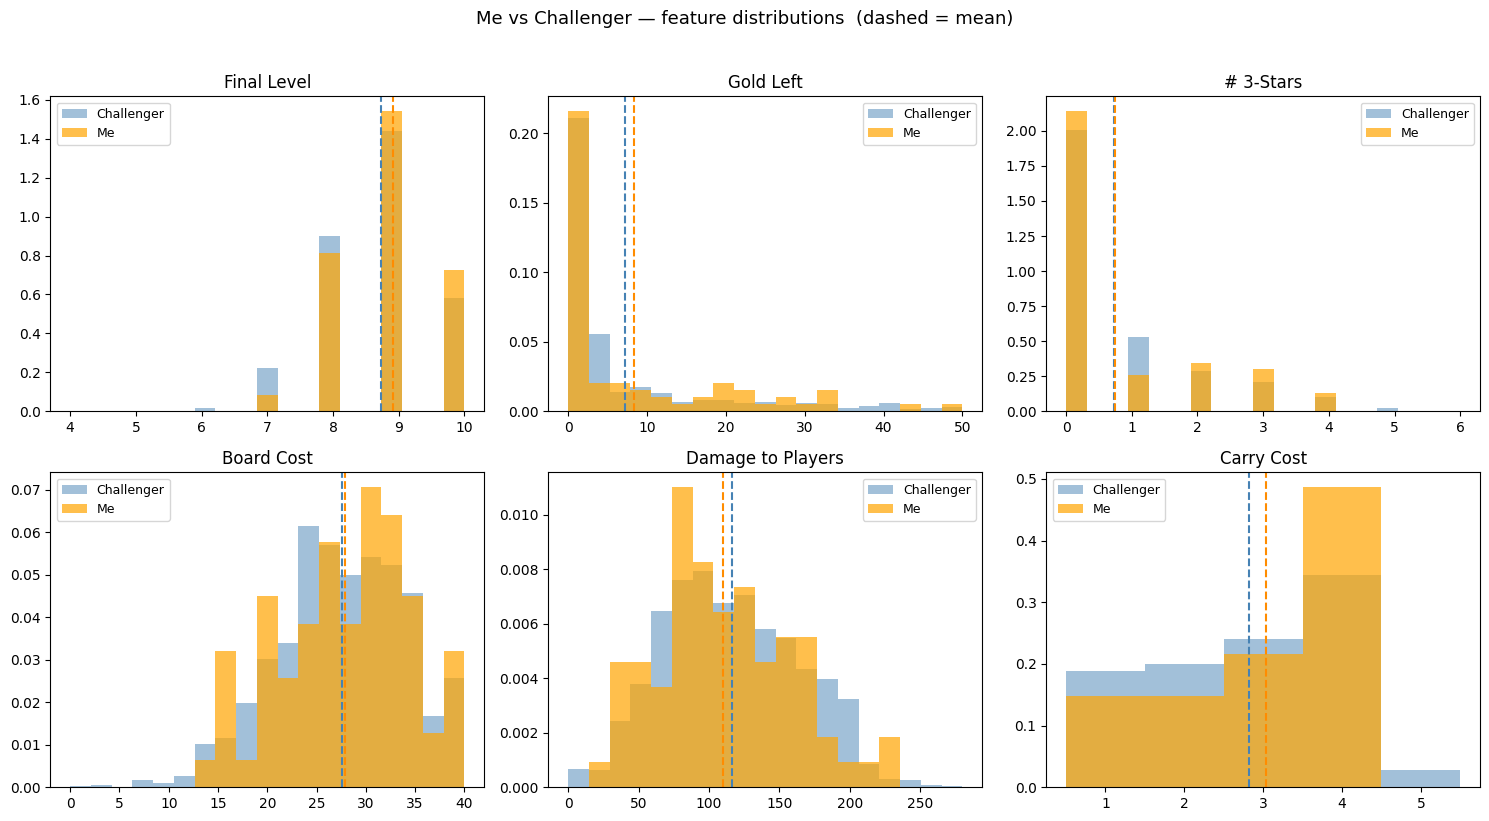

,me_mean,chall_mean,diff
level,8.92,8.74,0.18
gold_left,8.31,7.17,1.14
n_3stars,0.74,0.72,0.02
total_board_cost,27.89,27.55,0.34
damage_to_players,110.32,116.15,-5.83
carry_cost,3.04,2.82,0.22


In [30]:
overlay_features = [
    ("level",             "Final Level"),
    ("gold_left",         "Gold Left"),
    ("n_3stars",          "# 3-Stars"),
    ("total_board_cost",  "Board Cost"),
    ("damage_to_players", "Damage to Players"),
    ("carry_cost",        "Carry Cost"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, (feat, label) in zip(axes, overlay_features):
    if feat == "carry_cost":
        me_data    = me[me["carry_cost"].isin([1, 2, 3, 4, 5])]["carry_cost"]
        chall_data = chall[chall["carry_cost"].isin([1, 2, 3, 4, 5])]["carry_cost"]
        bins = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
    else:
        me_data    = me[feat].dropna()
        chall_data = chall[feat].dropna()
        bins = np.linspace(df[feat].dropna().min(), df[feat].dropna().max(), 20)

    ax.hist(chall_data, bins=bins, density=True, alpha=0.5, color="steelblue", label="Challenger")
    ax.hist(me_data,    bins=bins, density=True, alpha=0.7, color="orange",    label="Me")
    ax.axvline(chall_data.mean(), color="steelblue",  linestyle="--", linewidth=1.5)
    ax.axvline(me_data.mean(),    color="darkorange", linestyle="--", linewidth=1.5)
    ax.set_title(label)
    ax.legend(fontsize=9)

plt.suptitle("Me vs Challenger — feature distributions  (dashed = mean)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    "me_mean":    me[  [f for f, _ in overlay_features]].mean(),
    "chall_mean": chall[[f for f, _ in overlay_features]].mean(),
}).round(2)
summary["diff"] = (summary["me_mean"] - summary["chall_mean"]).round(2)
summary

## 4. Carry analysis

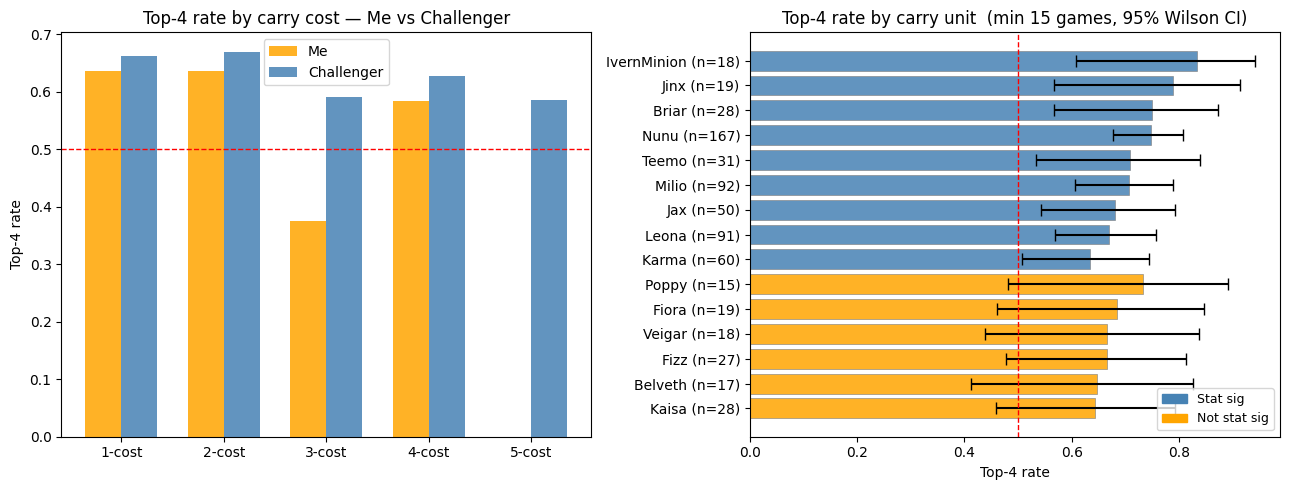

,games,top4_rate,stat_sig
carry_unit,,,
IvernMinion,18,0.833333,True
Jinx,19,0.789474,True
Briar,28,0.750000,True
Nunu,167,0.748503,True
Teemo,31,0.709677,True
Milio,92,0.706522,True
Jax,50,0.680000,True
Leona,91,0.670330,True
Karma,60,0.633333,True


In [38]:
def wilson_ci(successes, n, z=1.96):
    if n == 0:
        return 0, 0
    p = successes / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return center - margin, center + margin

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# grouped bar: top-4 rate by carry cost — me vs challenger
costs = sorted(df["carry_cost"].dropna().unique().astype(int))
x = np.arange(len(costs))
w = 0.35
me_rates    = [me[me["carry_cost"] == c]["top4"].mean()       if (me["carry_cost"] == c).any()    else np.nan for c in costs]
chall_rates = [chall[chall["carry_cost"] == c]["top4"].mean() if (chall["carry_cost"] == c).any() else np.nan for c in costs]
axes[0].bar(x - w/2, me_rates,    w, label="Me",         color="orange",    alpha=0.85)
axes[0].bar(x + w/2, chall_rates, w, label="Challenger", color="steelblue", alpha=0.85)
axes[0].axhline(0.5, color="red", linestyle="--", linewidth=1)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"{c}-cost" for c in costs])
axes[0].set_title("Top-4 rate by carry cost — Me vs Challenger")
axes[0].set_ylabel("Top-4 rate")
axes[0].legend()

# horizontal bar: top-4 rate by carry unit with 95% Wilson CI
cu = (df.groupby("carry_unit")
        .agg(wins=("top4", "sum"), games=("top4", "count"))
        .query("games >= 15")
        .copy())
cu["top4_rate"] = cu["wins"] / cu["games"]
ci = cu.apply(lambda r: wilson_ci(r["wins"], r["games"]), axis=1)
cu["err_lo"] = cu["top4_rate"] - ci.apply(lambda x: x[0])
cu["err_hi"] = ci.apply(lambda x: x[1]) - cu["top4_rate"]
cu["stat_sig"] = (
    (cu["top4_rate"] - cu["err_lo"] > 0.5) |
    (cu["top4_rate"] + cu["err_hi"] < 0.5)
)
# non-stat-sig at bottom, stat-sig at top; within each group sort by top4_rate
cu = cu.sort_values(["stat_sig", "top4_rate"], ascending=[True, True]).tail(15)
colors = ["steelblue" if s else "orange" for s in cu["stat_sig"]]

yp = range(len(cu))
axes[1].barh(list(yp), cu["top4_rate"],
             xerr=[cu["err_lo"].tolist(), cu["err_hi"].tolist()],
             color=colors, alpha=0.85, capsize=4, edgecolor="grey", linewidth=0.5)
axes[1].set_yticks(list(yp))
axes[1].set_yticklabels([f"{u} (n={n})" for u, n in zip(cu.index, cu["games"])])
axes[1].set_title("Top-4 rate by carry unit  (min 15 games, 95% Wilson CI)")
axes[1].set_xlabel("Top-4 rate")
axes[1].axvline(0.5, color="red", linestyle="--", linewidth=1)

from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color="steelblue", label="Stat sig"),
                         Patch(color="orange", label="Not stat sig")],
               loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()
cu[cu["stat_sig"] == True][["games", "top4_rate", "stat_sig"]].sort_values("top4_rate", ascending=False)


## 6. Trait analysis

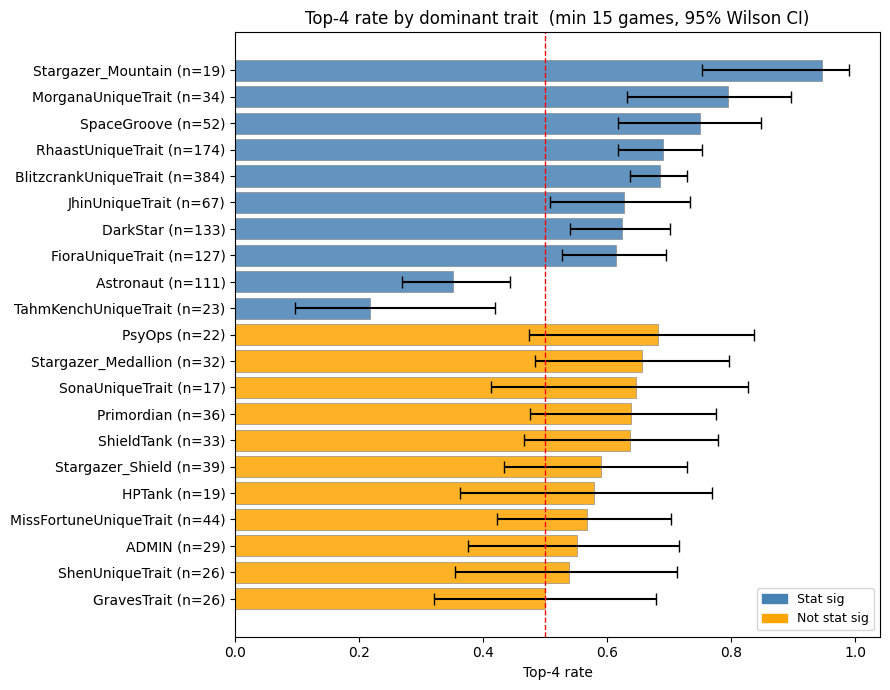

,games,top4_rate
dominant_trait,,
Stargazer_Mountain,19,0.947368
MorganaUniqueTrait,34,0.794118
SpaceGroove,52,0.750000
RhaastUniqueTrait,174,0.689655
BlitzcrankUniqueTrait,384,0.684896
JhinUniqueTrait,67,0.626866
DarkStar,133,0.624060
FioraUniqueTrait,127,0.614173
Astronaut,111,0.351351


In [41]:
trait_stats = (df.groupby("dominant_trait")
               .agg(wins=("top4", "sum"), games=("top4", "count"),
                    mean_placement=("placement", "mean"))
               .query("games >= 15")
               .copy())
trait_stats["top4_rate"] = trait_stats["wins"] / trait_stats["games"]
ci = trait_stats.apply(lambda r: wilson_ci(r["wins"], r["games"]), axis=1)
trait_stats["err_lo"] = trait_stats["top4_rate"] - ci.apply(lambda x: x[0])
trait_stats["err_hi"] = ci.apply(lambda x: x[1]) - trait_stats["top4_rate"]
trait_stats["stat_sig"] = (
    (trait_stats["top4_rate"] - trait_stats["err_lo"] > 0.5) |
    (trait_stats["top4_rate"] + trait_stats["err_hi"] < 0.5)
)
trait_stats = trait_stats.sort_values(["stat_sig", "top4_rate"], ascending=[True, True])
colors = ["steelblue" if s else "orange" for s in trait_stats["stat_sig"]]

fig, ax = plt.subplots(figsize=(9, 7))
yp = range(len(trait_stats))
ax.barh(list(yp), trait_stats["top4_rate"],
        xerr=[trait_stats["err_lo"].tolist(), trait_stats["err_hi"].tolist()],
        color=colors, alpha=0.85, capsize=4, edgecolor="grey", linewidth=0.5)
ax.set_yticks(list(yp))
ax.set_yticklabels([f"{t} (n={n})" for t, n in zip(trait_stats.index, trait_stats["games"])])
ax.set_title("Top-4 rate by dominant trait  (min 15 games, 95% Wilson CI)")
ax.set_xlabel("Top-4 rate")
ax.axvline(0.5, color="red", linestyle="--", linewidth=1)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="steelblue", label="Stat sig"),
                   Patch(color="orange",    label="Not stat sig")],
          loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()
trait_stats[trait_stats["stat_sig"]][["games", "top4_rate"]].sort_values("top4_rate", ascending=False)